In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv(r"C:\Users\acer\Documents\data-pipeline-assignment\data\raw\automobileEDA_dirty_training.csv")
# data display pertama
display(data.head())
# info data tersebut
display(data.info())

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,01-03-2025,1,122,ALFA-ROMERO,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,04-Jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_date   203 non-null    str    
 1   symboling          205 non-null    int64  
 2   normalized-losses  205 non-null    int64  
 3   make               203 non-null    str    
 4   aspiration         205 non-null    str    
 5   num-of-doors       203 non-null    str    
 6   body-style         205 non-null    str    
 7   drive-wheels       205 non-null    str    
 8   engine-location    205 non-null    str    
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    str    
 15  num-of-cylinders   205 non-null    str    
 16  engine-size        205 non-null    in

None

# Penjelasannya:
Cara 1
- Ada yang aneh tarsaksi date beda penulisannya gak konstan
- merk (make) ada huruf besar sama huruf kecil
perlu di cleaning atau pembersihan
Data columns (total 30 columns) dan 205 baris
- diatas gak semua nya full ada berapa isi value (full nya 205, tapi ada yang 203)
- Ad yang harus diperhatikan tipe data :
a. Kalo tipe data nya str(string) 99% bahwa tipe kategorikal
b. Kalo tipe float juga 99% tipe nya numerikal
 
 tapi untuk tipe int perlu chek apakah bener numeruikal atau kategorikal yang di represantikan dengan angka. cara nge chek nya kita bisa lihat berdasarkan distribusi dari setiap nilai seberapa banayak kemunculan nilainya menggunakan inspect data seperti dibawah:

In [4]:
## Cara 1
# List inspect data, cth symboling  (diambil dari atas dataset))
inspect_data = ['symboling','normalized-losses','curb-weight','engine-size','city-mpg','highway-mpg','diesel','gas']

for ins in inspect_data:
    display(data[ins].value_counts())


symboling
 0    67
 1    53
 2    33
 3    27
-1    22
-2     3
Name: count, dtype: int64

normalized-losses
122    43
161    11
91      8
150     7
104     6
128     6
134     6
148     5
85      5
103     5
168     5
74      5
102     5
65      5
94      5
95      5
118     4
106     4
93      4
137     3
101     3
115     3
125     3
108     3
154     3
83      3
164     2
158     2
192     2
188     2
81      2
110     2
145     2
113     2
129     2
153     2
194     2
119     2
89      2
87      2
197     2
121     1
98      1
78      1
107     1
142     1
231     1
186     1
77      1
90      1
256     1
Name: count, dtype: int64

curb-weight
1989    4
2385    4
1918    3
2275    3
2548    2
       ..
2952    1
3049    1
3012    1
3217    1
3062    1
Name: count, Length: 169, dtype: int64

engine-size
122    16
92     15
98     14
97     14
108    13
110    12
90     11
109     8
120     7
181     7
141     7
152     6
136     6
121     6
146     6
156     5
91      5
130     4
183     4
164     3
209     3
70      3
194     3
171     3
258     2
140     2
134     2
234     2
132     2
131     1
61      1
79      1
111     1
119     1
326     1
80      1
308     1
304     1
103     1
151     1
161     1
173     1
145     1
Name: count, dtype: int64

city-mpg
19    29
31    29
24    22
27    14
17    12
23    12
26    12
21     8
30     8
25     8
28     7
37     6
16     5
38     5
22     4
18     3
20     3
15     3
29     3
36     2
14     2
47     1
49     1
13     1
45     1
32     1
35     1
34     1
33     1
Name: count, dtype: int64

highway-mpg
25    21
38    18
24    17
30    16
32    16
34    14
37    13
28    12
29    10
33     9
31     8
22     7
23     7
27     5
42     4
26     3
41     3
20     2
43     2
19     2
39     2
18     2
16     2
36     2
47     2
46     2
53     1
54     1
17     1
50     1
Name: count, dtype: int64

diesel
0    184
1     21
Name: count, dtype: int64

gas
1    184
0     21
Name: count, dtype: int64

<details> 
<summary> Penjelasan Data Type (Kategorikal vs Numerikal)</summary>

### A. Symboling
- Ada 6 jenis nilai: (0, 1, 2, 3, -1, -2)
- **Tipe:** Kategorikal

### B. Normalized-losses
- Banyak distribusi nilainya
- **Tipe:** Numerikal

### C. Curb-Weight
- Pasti numerikal karena merupakan berat (weight)
- **Tipe:** Numerikal

### D. Engine-size
- **Tipe:** Numerikal

### E. City-mpg
- **Tipe:** Numerikal

### F. Highway-mpg
- **Tipe:** Numerikal

### G. Diesel dan Gas
- Menyatakan bahan bakar
- Diesel = 1 jika bensin diesel, Gas = 1 jika bensin gas
- Nilai kebalikan dalam tabel
- **Tipe:** Kategorikal

---

### Kesimpulan:
- **Kolom Kategorikal tambahan:** symboling, diesel, gas
- **Alasan metode ini:** Digunakan ketika tidak punya metadata lengkap
- **Jika ada metadata:** Langsung bisa baca distribusi setiap kolom tanpa perlu cek manual
- **Referensi:** Automobile dataset tersedia di Kaggle
- **Prosedur:** Jika tidak ada penjelasan deskripsi kolom, cek manual yang mana kategorikal atau numerikal

</details>

### abis itu list yang mana kategorikal atau numerikal :

In [6]:
# Cara 2
# list kategorikal atau numerikal
# copy dulu data krn kita gak akan merubah data aslinya
data_raw = data.copy()
#kita definisikan atau kategorikan kollom
categorical_columns = list(data_raw.select_dtypes(include="str").columns)

# tambahkan concet suatu list dengan list lainnya
# gimana cara menggabungkan  anatar list dan data yang kategorkan ada 3 tambahan :simboling diesel sama gas
# gimana kita gabungkan dia dengan list yang baru :
categorical_columns += ["symboling", "diesel", "gas"]
print("------------Categorical Columns------------")
display(categorical_columns)
numerical_columns = list(data_raw.select_dtypes(include="number").columns)
# di numerical collum masih ada simboling, diesel, dan gas yang seharusnya masuk ke kategorikal
# cara hapus elemn tersebut pakai fungsi pop atau remove
numerical_columns.remove("symboling")
numerical_columns.remove("diesel")
numerical_columns.remove("gas")
print("-------------numerical Columns updated-------------")
display(numerical_columns)



------------Categorical Columns------------


['transaction_date',
 'make',
 'aspiration',
 'num-of-doors',
 'body-style',
 'drive-wheels',
 'engine-location',
 'engine-type',
 'num-of-cylinders',
 'fuel-system',
 'horsepower-binned',
 'symboling',
 'diesel',
 'gas']

-------------numerical Columns updated-------------


['normalized-losses',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-size',
 'bore',
 'stroke',
 'compression-ratio',
 'horsepower',
 'peak-rpm',
 'city-mpg',
 'highway-mpg',
 'price',
 'city-L/100km']

### Lanjut
Setelah sudah dibagi antara kategorikal sama numerikal selanjutnya
1. menyamakan format yang collomnya merk penulisannya masih gak konsisten balik ke awal saat penunjukan data biasanya kita ubah yang huruf besar ke huruf kecil semua
jadi kita tambahakan Cleansing Categorical Data

## Cleansing Categorical Data

In [7]:
#   Cara 3
for category in  categorical_columns:
    #membuat semunya jadi huruf kecil dengan cara fungsi str.lower()
    # perlu diperhatikan in case ada spasi2 yang masukke penulisan merk misal alfa_romero atau
    # yang merk lain ada spasinya kita bisa hapus spasi yang gak berguna dengan cara .str.strip()
    # ada yang harus diubah tipe data dari int jadi str yaitu solar sama bensin 0 1 cara .astype(str)
    data_raw[category] = data_raw[category].astype("str").str.lower().str.strip()
    
# Sekarang bisa lihat, taro diluar for biar bisa tampil
data_raw.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,02/01/2025,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,01-03-2025,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,04-jan-2025,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-01-05,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


### sudah tidak ada huruf2 besarnya, trus yang perlu dibersihkan tanggalnya atau date

jadi tipe tanggal itu tipe data nya sudah ada: string, object ,int date/time, float jadi kita bisa gunakan fungsi pandasnya

In [8]:
#cara 4
# date time pd.to_datetime Karena ini harus di ubah tipe data dari string to datetime pandas
data_raw["transaction_date"] = pd.to_datetime(data_raw["transaction_date"], dayfirst=True, format="mixed")
data_raw.head()

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,2025-01-01,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,medium,0,1
1,2025-01-02,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,medium,0,1
2,2025-03-01,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,medium,0,1
3,2025-01-04,2,164,audi,std,four,sedan,fwd,front,99.8,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,medium,0,1
4,2025-05-01,2,164,audi,std,four,sedan,4wd,front,99.4,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,medium,0,1


<details>
<summary>Langkah ke 5</summary>

Setelah tadi membedakan dan memperbaiki categorical, numerikal, dan seragamkan tulisan menjadi angka kecil trus memperbaiki date/time, kita harus isi missing value.

Karena total baris (RangeIndex) ada 205, maka kolom yang memiliki Non-Null Count kurang dari 205 menandakan ada data yang kosong (missing values/NaN).

### Kolom Categorical yang Memiliki Data Kosong (< 205):
- **make:** 203 non-null (ada 2 data kosong)
- **num-of-doors:** 203 non-null (ada 2 data kosong)
- **transaction_date:** 203 non-null (ada 2 data kosong)
  - Untuk date/tanggal gpp kosong, kita biasanya ketika ingin menggunakan tanggal sebagai feature untuk prediksi, kita perlu melakukan feature engineering lagi
  - Jadi gak bisa langsung masukkan tgl
  - Kita buat kolom turunan dari tanggal (tahun, bulan, tanggal)

### Penanganan Data Cleaning:
- **2 data kosong pada make dan num-of-doors** perlu diisi (imputation)
- Gunakan **modus** (nilai yang paling sering muncul)
- **Median dan mean tidak bisa** karena ini untuk kategorikal, bukan numerikal

</details>

In [9]:
# Cara 5
# Mengisi nilai yang kosong pada cetgorical dengan modus (nilai yang paling sering muncul)
# modus : .mode()
# keluaran dari function mode() adalah sebuah Series bisa lebih dari satu value 
# krn nilai yang paling sering muncul kan bisa lebih dari satu kan dia
# itu makanya bentuk nya string, nah kita pilih yang paling pertama
# saja nilai modus yang pertama digunakan [0]
# 

for category in categorical_columns:
    data_raw[category] = data_raw[category].fillna(data_raw[category].mode()[0])
    
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_date   205 non-null    datetime64[us]
 1   symboling          205 non-null    str           
 2   normalized-losses  205 non-null    int64         
 3   make               205 non-null    str           
 4   aspiration         205 non-null    str           
 5   num-of-doors       205 non-null    str           
 6   body-style         205 non-null    str           
 7   drive-wheels       205 non-null    str           
 8   engine-location    205 non-null    str           
 9   wheel-base         205 non-null    float64       
 10  length             205 non-null    float64       
 11  width              205 non-null    float64       
 12  height             205 non-null    float64       
 13  curb-weight        205 non-null    int64         
 14  engine-type        20

<details>
<summary>Cleansing Numerical</summary>
1. Gak bisa sembarangan melakukan data preporcessing atau cleaning, kita perlu melihat distrubusi datanya terus out layer</details>


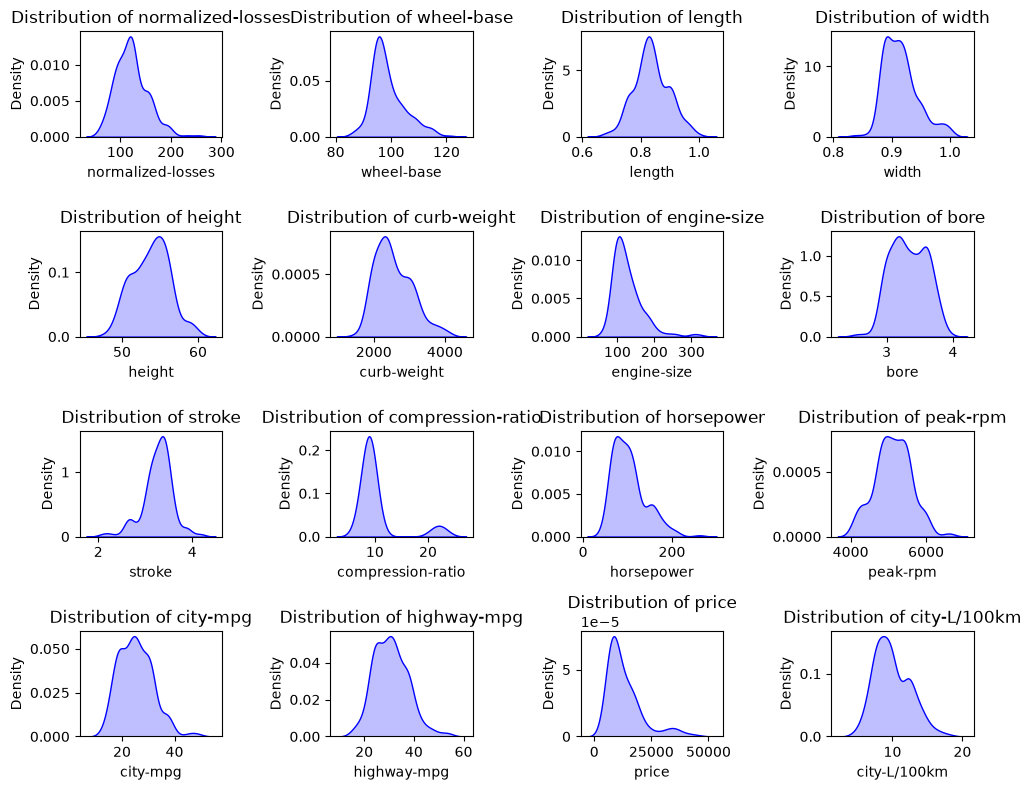

In [10]:
#cara ke 7
# #Gak bisa sembarangan melakukan data preporcessing atau 
# cleaning, kita perlu melihat distrubusi datanya terus out layer
# kita buat histogram pandas, import matlopolip, seaborn
import matplotlib.pyplot as plt
import seaborn as sns

#kita buat jadi miring jumalh ada 16
# Membuat area grafik berukuran 4 baris × 4 kolom
fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(10, 8)
)

# Mengubah axes menjadi array satu dimensi
axes = axes.flatten()

# Mengulang setiap kolom numerik
for i, category in enumerate(numerical_columns):
    # Membuat grafik KDE untuk kolom saat ini
    sns.kdeplot(
        data=data_raw,
        x=category,
        fill=True,
        color="blue",
        ax=axes[i]
    )

    # Memberi judul sesuai nama kolom
    axes[i].set_title(f"Distribution of {category}")

# Merapikan jarak antar-grafik
plt.tight_layout()

# Menampilkan seluruh grafik setelah loop selesai
plt.show()

<details>
<summary>Penjelasan Langkah 7 - Missing Values Berdasarkan Distribusi</summary>

## Konsep Dasar
Untuk mengisi missing values pada kolom numerik, kita **tidak bisa sembarangan** pilih mean atau median. Harus disesuaikan dengan **bentuk distribusi data**-nya.

---

### Kolom dengan Distribusi Normal (Gaussian/Bell Curve)
**Ciri visual:** Berbentuk lonceng, satu puncak, simetris

**Kolom:**
- Wheel-base
- Length
- Height
- Width (agak miring)
- Peak-rpm
- City-mpg
- Highway-mpg

**Handling:** Isi dengan **MEAN** (rata-rata)
- Alasan: Data terdistribusi seimbang, mean representative untuk nilai sentral

---

### Kolom dengan Distribusi Right-Skewed (Miring ke Kanan)
**Ciri visual:** Ekor panjang di sisi kanan, puncak di kiri

**Kolom:**
- Normalized-losses
- Engine-size
- Horsepower
- Price
- City-L/100km
- Compression-ratio

**Handling:** Isi dengan **MEDIAN** (nilai tengah)
- Alasan: Ada outlier besar, MEDIAN lebih robust dan tidak terpengaruh nilai ekstrem



## Missing Values Summary - Kolom Numerik

| Kolom | Total Baris | Non-Null | Missing | Distribusi | Imputation |
|-------|-------------|----------|---------|------------|------------|
| stroke | 205 | 201 | 4 | Agak normal | **MEAN** |
| horsepower | 205 | 202 | 3 | Right-skewed | **MEDIAN** |
| price | 205 | 202 | 3 | Right-skewed | **MEDIAN** |

---

## Strategi Imputation Ringkas

| Tipe Distribusi | Strategi | Alasan |
|-----------------|----------|--------|
| **Normal** | MEAN | Data simetris, mean adalah pusat |
| **Skewed** | MEDIAN | Robust terhadap outlier |
| **Bimodal/Special** | MEDIAN | Aman untuk bentuk tidak standar |

---

## kesimpulan
- **Jangan gunakan MEAN** pada data skewed (terlalu terpengaruh outlier)
- **Jangan gunakan MEDIAN** pada data perfectly normal (kehilangan informasi)
- **Selalu lihat visual distribusi dulu** sebelum memilih strategi imputation
- Alternative: Bisa juga gunakan **mode**, **forward fill**, atau **model-based imputation** tergantung konteks bisnis

</details>

In [12]:
#Cara ke 8
#Gampangnya kalo dia gambarnya normal kita ganti dengan min.
#kalo gambarnya skew kita ganti dengan median
# stroke
data_raw['stroke'] = data_raw['stroke'].fillna(data_raw['stroke'].mean())
data_raw['horsepower'] = data_raw['horsepower'].fillna(data_raw['horsepower'].median())
data_raw['price'] = data_raw['price'].fillna(data_raw['price'].median())

# chek
data_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_date   205 non-null    datetime64[us]
 1   symboling          205 non-null    str           
 2   normalized-losses  205 non-null    int64         
 3   make               205 non-null    str           
 4   aspiration         205 non-null    str           
 5   num-of-doors       205 non-null    str           
 6   body-style         205 non-null    str           
 7   drive-wheels       205 non-null    str           
 8   engine-location    205 non-null    str           
 9   wheel-base         205 non-null    float64       
 10  length             205 non-null    float64       
 11  width              205 non-null    float64       
 12  height             205 non-null    float64       
 13  curb-weight        205 non-null    int64         
 14  engine-type        20

## Data Transformation


## Transformasi
1. normalisasi : kita ingin melakukan analaisis sendiri gambar output yang ada di numerical tadi apa gitu. sekarang semuanya pakai min-max scale
min -max scale

In [13]:
# min -max scale
#Pakai library sklearn library biasa digunakan untuk pembuatn model machine leaning
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_raw[numerical_columns] = scaler.fit_transform(data_raw[numerical_columns])

display(data_raw[numerical_columns].head())

,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km
0,0.298429,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.1250,0.294393,0.346939,0.222222,0.289474,0.207959,0.481481
1,0.298429,0.058309,0.413433,0.324786,0.083333,0.411171,0.260377,0.664286,0.290476,0.1250,0.294393,0.346939,0.222222,0.289474,0.282558,0.481481
2,0.298429,0.230321,0.449254,0.444444,0.383333,0.517843,0.343396,0.100000,0.666667,0.1250,0.495327,0.346939,0.166667,0.263158,0.282558,0.570175
3,0.518325,0.384840,0.529851,0.504274,0.541667,0.329325,0.181132,0.464286,0.633333,0.1875,0.252336,0.551020,0.305556,0.368421,0.219254,0.376157
4,0.518325,0.373178,0.529851,0.521368,0.541667,0.518231,0.283019,0.464286,0.633333,0.0625,0.313084,0.551020,0.138889,0.157895,0.306142,0.621914


<details>
<summary>Kesimpulan Data Transformation</summary>

Semua kolom numerik telah dilakukan **Min-Max Scaling** menggunakan `MinMaxScaler`. Hasil scaling berada pada rentang **0 sampai 1**.

Perlu diperhatikan bahwa Min-Max Scaling  mengubah skala atau rentang nilai.

Berdasarkan pemeriksaan distribusi, tidak terlihat adanya skewness yang ekstrem pada kolom numerik. Oleh karena itu, transformasi tambahan belum diperlukan.

Jika terdapat skewness yang tinggi, beberapa transformasi yang dapat digunakan adalah:

- Log Transformation
- Yeo-Johnson Transformation
- Box-Cox Transformation

</details>

<details>
<summary>Transformasi Data Kategorikal</summary>

Sebelum melakukan transformasi pada data kategorikal, perlu diperiksa terlebih dahulu isi setiap kolom menggunakan `value_counts()`

`value_counts()` digunakan untuk mengetahui jumlah dan distribusi setiap kategori pada kolom kategorikal. Hasil pemeriksaan ini membantu menentukan metode encoding yang sesuai.

Kolom `transaction_date` tidak digunakan dalam transformasi data kategorikal, sehingga kolom tersebut dihapus. Jika tanggal diperlukan untuk analisis, tanggal dapat diolah terlebih dahulu menjadi fitur seperti tahun, bulan, atau hari.
</details>

In [14]:
categorical_columns.remove("transaction_date")

In [15]:
for category in categorical_columns:
    display(data_raw[category].value_counts())

make
toyota           35
mazda            18
nissan           17
honda            12
mitsubishi       12
subaru           12
volkswagen       12
volvo            11
dodge            10
peugot           10
bmw               9
audi              8
mercedes-benz     8
plymouth          7
saab              6
porsche           4
alfa-romero       3
chevrolet         3
jaguar            3
isuzu             2
renault           2
mercury           1
Name: count, dtype: int64

aspiration
std      169
turbo     36
Name: count, dtype: int64

num-of-doors
four    119
two      86
Name: count, dtype: int64

body-style
sedan          98
hatchback      69
wagon          24
hardtop         8
convertible     6
Name: count, dtype: int64

drive-wheels
fwd    121
rwd     75
4wd      8
awd      1
Name: count, dtype: int64

...

fuel-system
mpfi    96
2bbl    64
idi     20
1bbl    11
spdi     9
4bbl     3
mfi      1
spfi     1
Name: count, dtype: int64

horsepower-binned
low       118
medium     64
high       23
Name: count, dtype: int64

symboling
0     67
1     53
2     33
3     27
-1    22
-2     3
Name: count, dtype: int64

diesel
0    184
1     21
Name: count, dtype: int64

gas
1    184
0     21
Name: count, dtype: int64

<details>
<summary>Penjelasan Transformasi Data Kategorikal</summary>

`value_counts()` digunakan untuk mengetahui jumlah dan distribusi setiap kategori pada kolom kategorikal. Hasil pemeriksaan ini membantu menentukan metode encoding yang sesuai.

### 1. `make`
- Bersifat **nominal** karena merepresentasikan merek tanpa urutan.
- Memiliki banyak kategori.
- Dapat menggunakan **frequency encoding** agar jumlah kolom tidak terlalu banyak.

### 2. `aspiration`
- Memiliki dua kategori: `std` dan `turbo`.
- Bersifat **nominal**.
- Dapat diubah menggunakan **binary encoding**, misalnya menjadi `0` dan `1`.

### 3. `num-of-doors`
- Memiliki dua kategori: `two` dan `four`.
- Menunjukkan jumlah pintu, sehingga dapat diperlakukan sebagai nilai numerik.
- Nilai `two` diubah menjadi `2`, sedangkan `four` diubah menjadi `4`.

### 4. `body-style`
- Bersifat **nominal** karena kategorinya tidak memiliki urutan.
- Memiliki beberapa kategori, sehingga dapat menggunakan **one-hot encoding**.

### 5. `drive-wheels`
- Bersifat **nominal**.
- Setiap kategori menunjukkan jenis penggerak yang berbeda.
- Dapat menggunakan **one-hot encoding**.

### 6. `engine-location`
- Memiliki dua kategori, yaitu `front` dan `rear`.
- Bersifat **nominal**.
- Dapat menggunakan **binary encoding** atau one-hot encoding.

### 7. `engine-type`
- Bersifat **nominal**.
- Memiliki beberapa kategori.
- Dapat menggunakan **frequency encoding** untuk menghindari terlalu banyak kolom baru.

### 8. `num-of-cylinders`
- Menunjukkan jumlah silinder, sehingga dapat diperlakukan sebagai nilai numerik.
- Nilai seperti `two`, `three`, `four`, dan seterusnya diubah menjadi angka.

### 9. `fuel-system`
- Bersifat **nominal** karena menunjukkan jenis sistem bahan bakar.
- Dapat menggunakan **frequency encoding** atau one-hot encoding.

### 10. `horsepower-binned`
- Bersifat **ordinal** karena kategorinya memiliki tingkatan, misalnya `low`, `medium`, dan `high`.
- Dapat menggunakan **ordinal encoding** atau label encoding dengan urutan:
  `low = 0`, `medium = 1`, dan `high = 2`.

Pemilihan metode encoding dilakukan berdasarkan jenis data, jumlah kategori, dan ada atau tidaknya urutan antar kategori.

</details>

In [16]:
frequency_encoding = ["make", "engine-type", "fuel-system"]
one_hot = ["body-style", "drive-wheels"]
label_encoding = [
    "aspiration",
    "engine-location",
    "horsepower-binned"
]

# One-hot encoding
data_raw = pd.get_dummies(data_raw, columns=one_hot)

# Frequency encoding
for col in frequency_encoding:
    freq = data_raw[col].value_counts(normalize=True)
    data_raw[col] = data_raw[col].map(freq)

# Label encoding
from sklearn.preprocessing import LabelEncoder

for col in label_encoding:
    le = LabelEncoder()
    data_raw[col] = le.fit_transform(data_raw[col].astype(str))

data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_date        205 non-null    datetime64[us]
 1   symboling               205 non-null    str           
 2   normalized-losses       205 non-null    float64       
 3   make                    205 non-null    float64       
 4   aspiration              205 non-null    int64         
 5   num-of-doors            205 non-null    str           
 6   engine-location         205 non-null    int64         
 7   wheel-base              205 non-null    float64       
 8   length                  205 non-null    float64       
 9   width                   205 non-null    float64       
 10  height                  205 non-null    float64       
 11  curb-weight             205 non-null    float64       
 12  engine-type             205 non-null    float64       
 13  n

disini udah hampir semua jadi enggak ada string, symboling ubah lagi jadi int tadi gara2 kita masukkin ke categorical. temen2 nanti ubah nya yang num-of-door, num-of-silinder dia harus bener2 mapping secara manual kareana namanya sepertinya dia numerical dari namanya keliatan (four, two) jadi mappingnya secara manual biar masuk ke categorical

In [17]:
# kita ubah kembali jadi int
data_raw['symboling'] = data_raw['symboling'].astype("int")
data_raw['diesel'] = data_raw['diesel'].astype("int")
data_raw['gas'] = data_raw['gas'].astype("int")
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   transaction_date        205 non-null    datetime64[us]
 1   symboling               205 non-null    int64         
 2   normalized-losses       205 non-null    float64       
 3   make                    205 non-null    float64       
 4   aspiration              205 non-null    int64         
 5   num-of-doors            205 non-null    str           
 6   engine-location         205 non-null    int64         
 7   wheel-base              205 non-null    float64       
 8   length                  205 non-null    float64       
 9   width                   205 non-null    float64       
 10  height                  205 non-null    float64       
 11  curb-weight             205 non-null    float64       
 12  engine-type             205 non-null    float64       
 13  n

## Data pipelining 
bagaiman membuat semua pemrosesan ntadi itu menjadi otomatis.karena kita sudah melakukan analisis secara manual yang mana harus dilakukan one hot, label encoding, dst sekarang kita ingin membuatnya secara ototmatis

In [20]:
# kita harus membutanya menjadi fungsi2 yang dia itu harus jalan dalam satu fungsi utama
# kita harus keluarkan dulu yang scaling2 nya yang pemanggilan, kenapa dikeluarkan biar 
# itu dipanggilnya cuma sekali,tidak setiap kita melukan otomatisasi itu memanggil

scaler = MinMaxScaler()
le = LabelEncoder()
frequency_encoding = ["make", "engine-type", "fuel-system"]
one_hot = ["body-style", "drive-wheels"]
label_encoding = ["aspiration", "engine-location", "horsepower-binned"]


def load_data(filename):
  data = pd.read_csv(filename)
  display(data.head())
  display(data.info())

  return data


def data_cleansing(data):
    data_raw = data.copy()

    for category in categorical_columns:
        data_raw[category] = data_raw[category].astype("str").str.lower().str.strip()

    data_raw['transaction_date'] = pd.to_datetime(data_raw['transaction_date'], dayfirst=True, format="mixed")

    for category in categorical_columns:
        data_raw[category] = data_raw[category].fillna(data_raw[category].mode()[0])

    data_raw['stroke'] = data_raw['stroke'].fillna(data_raw['stroke'].mean())
    data_raw['horsepower'] = data_raw['horsepower'].fillna(data_raw['horsepower'].median())
    data_raw['price'] = data_raw['price'].fillna(data_raw['price'].median())
    
    return data_raw


def data_transformation(data_raw):
  data_raw[numerical_columns] = scaler.fit_transform(data_raw[numerical_columns])
  data_raw = pd.get_dummies(data_raw, columns=one_hot)

  # Freq Encoding
  for col in frequency_encoding:
    freq = data_raw[col].value_counts(normalize=True)
    data_raw[col] = data_raw[col].map(freq)

  for col in label_encoding:
    data_raw[col] = le.fit_transform(data_raw[col].astype(str))

  return data_raw
    
#mengubah menjadi csv yang baru
#mengubah menjadi csv yang baru
def save_data(data_raw):
    output_path = r"C:\Users\acer\Documents\data-pipeline-assignment\data\processed"

    import os
    os.makedirs(output_path, exist_ok=True)

    data_raw.to_csv(
        os.path.join(output_path, "preprocessed_data.csv"),
        index=False
    )
    
def pipelining_data(filename):
  data = load_data(filename)
  data_raw = data_cleansing(data)
  data_raw = data_transformation(data_raw)
  save_data(data_raw)

In [23]:
pipelining_data(
    r"C:\Users\acer\Documents\data-pipeline-assignment\data\raw\automobileEDA_dirty_training.csv"
)

,transaction_date,symboling,normalized-losses,make,aspiration,num-of-doors,engine-location,wheel-base,length,width,...,gas,body-style_convertible,body-style_hardtop,body-style_hatchback,body-style_sedan,body-style_wagon,drive-wheels_4wd,drive-wheels_awd,drive-wheels_fwd,drive-wheels_rwd
0,2025-01-01,3,0.298429,0.014634,0,two,0,0.058309,0.413433,0.324786,...,1,True,False,False,False,False,False,False,False,True
1,2025-01-02,3,0.298429,0.014634,0,two,0,0.058309,0.413433,0.324786,...,1,True,False,False,False,False,False,False,False,True
2,2025-03-01,1,0.298429,0.014634,0,two,0,0.230321,0.449254,0.444444,...,1,False,False,True,False,False,False,False,False,True
3,2025-01-04,2,0.518325,0.039024,0,four,0,0.384840,0.529851,0.504274,...,1,False,False,False,True,False,False,False,True,False
4,2025-05-01,2,0.518325,0.039024,0,four,0,0.373178,0.529851,0.521368,...,1,False,False,False,True,False,True,False,False,False


<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 37 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_date        203 non-null    str    
 1   symboling               205 non-null    int64  
 2   normalized-losses       205 non-null    float64
 3   make                    205 non-null    float64
 4   aspiration              205 non-null    int64  
 5   num-of-doors            205 non-null    str    
 6   engine-location         205 non-null    int64  
 7   wheel-base              205 non-null    float64
 8   length                  205 non-null    float64
 9   width                   205 non-null    float64
 10  height                  205 non-null    float64
 11  curb-weight             205 non-null    float64
 12  engine-type             205 non-null    float64
 13  num-of-cylinders        205 non-null    str    
 14  engine-size             205 non-null    float64
 15  

None

KeyError: 'body-style'